In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/final_dataset.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")

In [5]:
import numpy as np

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["lag_24"] = df["price"].shift(24)
df["lag_48"] = df["price"].shift(48)
df["lag_168"] = df["price"].shift(168)

df["rolling_mean_24"] = df["price"].shift(1).rolling(24).mean()
df["rolling_std_24"] = df["price"].shift(1).rolling(24).std()

df["rolling_mean_48"] = df["price"].shift(1).rolling(48).mean()
df["rolling_mean_168"] = df["price"].shift(1).rolling(168).mean()

df = df.dropna()

In [6]:
train = df[: "2025-12-31"]
test = df["2026-01-01":]

In [7]:
features = [
    "hour", "dayofweek", "month","is_weekend",
    "hour_sin", "hour_cos",
    "lag_24", "lag_48", "lag_168",
    "rolling_mean_24", "rolling_std_24", "rolling_mean_48", "rolling_mean_168",
    "load", "wind", "solar"
]

X_train = train[features]
y_train = train["price"]

X_test = test[features]
y_test = test["price"]

In [8]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "objective": "reg:squarederror"
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)

    return mae

In [11]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

[I 2026-04-28 19:54:56,749] A new study created in memory with name: no-name-b7c54d66-6398-47c8-a2cd-052317fa904c
[I 2026-04-28 19:54:58,538] Trial 0 finished with value: 13.611395624390495 and parameters: {'n_estimators': 463, 'learning_rate': 0.13674586788076445, 'max_depth': 5, 'subsample': 0.6816258566693152, 'colsample_bytree': 0.7823345131173859}. Best is trial 0 with value: 13.611395624390495.
[I 2026-04-28 19:55:17,160] Trial 1 finished with value: 13.021083505203327 and parameters: {'n_estimators': 645, 'learning_rate': 0.06949898662279028, 'max_depth': 10, 'subsample': 0.6331531580043026, 'colsample_bytree': 0.7906156558575937}. Best is trial 1 with value: 13.021083505203327.
[I 2026-04-28 19:55:28,333] Trial 2 finished with value: 13.04733549795424 and parameters: {'n_estimators': 485, 'learning_rate': 0.16941034788412163, 'max_depth': 10, 'subsample': 0.9570605967411276, 'colsample_bytree': 0.8602685256841511}. Best is trial 1 with value: 13.021083505203327.
[I 2026-04-28 1

In [12]:
print("Best MAE:", study.best_value)
print("Best parameters:", study.best_params)

Best MAE: 11.893023349645237
Best parameters: {'n_estimators': 211, 'learning_rate': 0.08510427757060468, 'max_depth': 4, 'subsample': 0.9312507716824712, 'colsample_bytree': 0.8708683236759162}


In [13]:
best_params = study.best_params

model_xgb_opt = XGBRegressor(
    **best_params,
    random_state=42,
    objective="reg:squarederror"
)

model_xgb_opt.fit(X_train, y_train)

pred_xgb_opt = model_xgb_opt.predict(X_test)

mae_xgb_opt = mean_absolute_error(y_test, pred_xgb_opt)

print("XGBoost Bayesian Optimized MAE:", mae_xgb_opt)

XGBoost Bayesian Optimized MAE: 11.893023349645237


Error Analysis

In [ ]:
df_test = test.copy()

df_test["prediction"] = pred_xgb_opt   # your final predictions
df_test["error"] = df_test["price"] - df_test["prediction"]
df_test["abs_error"] = df_test["error"].abs()

In [18]:
df_test["abs_error"].describe()

count    960.000000
mean      11.893023
std       12.413694
min        0.011066
25%        3.999364
50%        8.297214
75%       15.740034
max      116.891529
Name: abs_error, dtype: float64

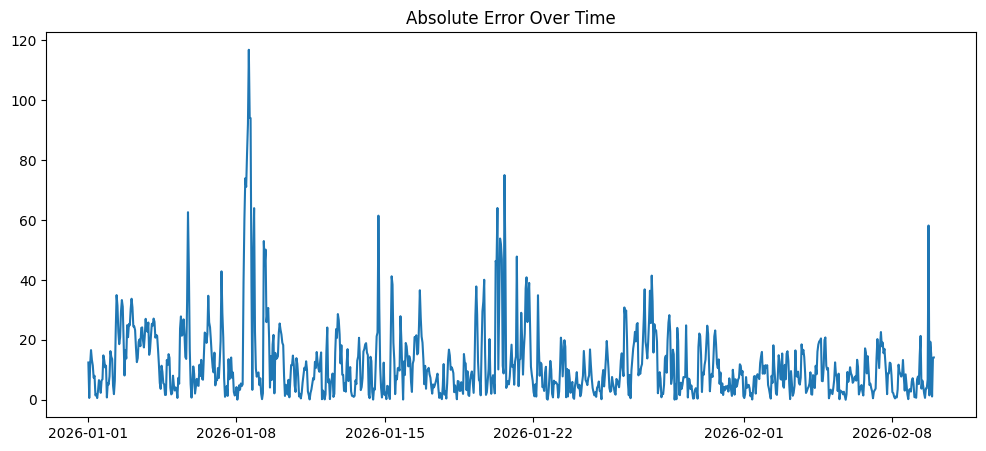

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_test.index, df_test["abs_error"])
plt.title("Absolute Error Over Time")
plt.show()

The model performs consistently most of the time but shows spikes in error during certain periods, indicating difficulty in capturing sudden price changes. <br>
Low values → model is accurate <br>
High spikes → model made big mistakes

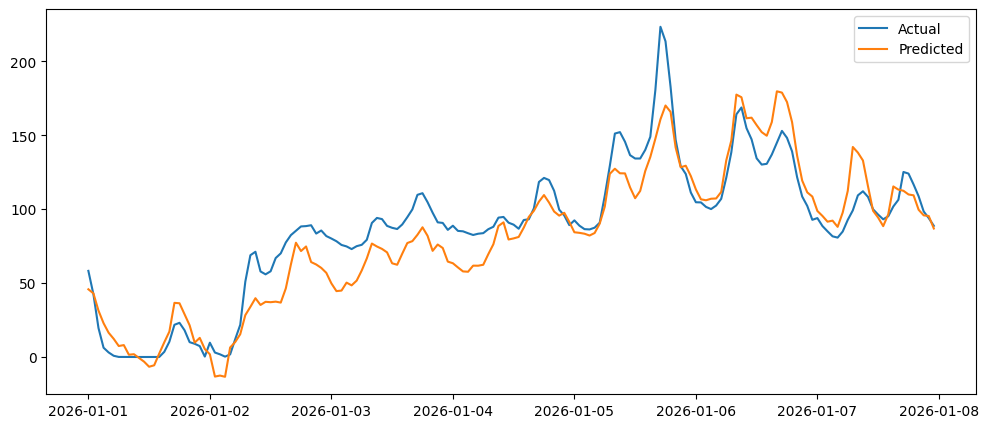

In [20]:
sample = df_test["2026-01-01":"2026-01-07"]

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample["price"], label="Actual")
plt.plot(sample.index, sample["prediction"], label="Predicted")
plt.legend()
plt.show()

The model follows the general trend well but struggles to capture sharp spikes and sudden drops in prices.

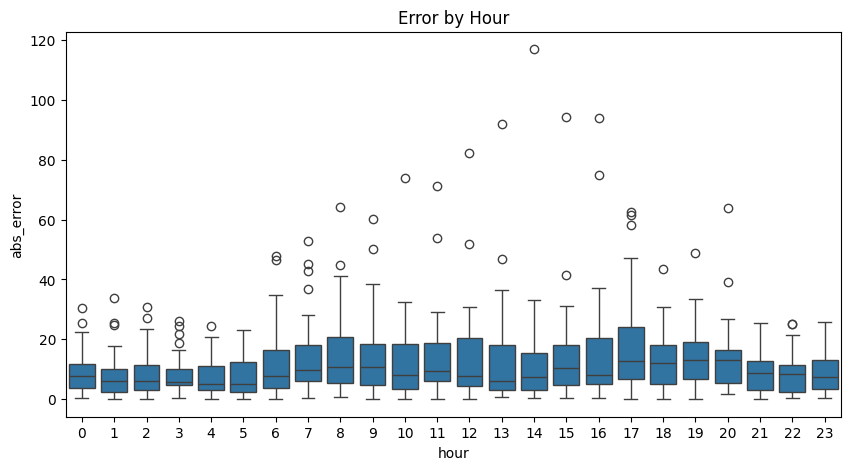

In [21]:
df_test["hour"] = df_test.index.hour

import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x="hour", y="abs_error", data=df_test)
plt.title("Error by Hour")
plt.show()

Errors are higher during certain hours (especially peak demand periods), suggesting that price dynamics are more complex during these times.

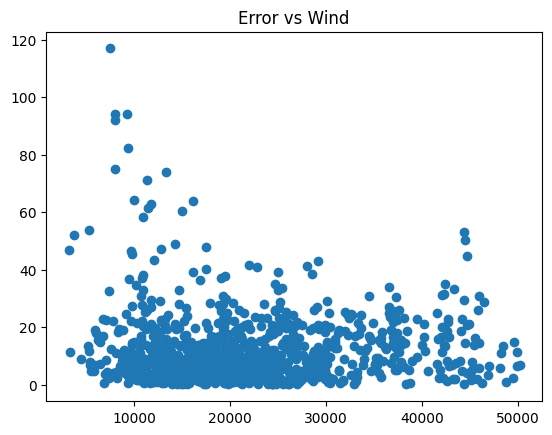

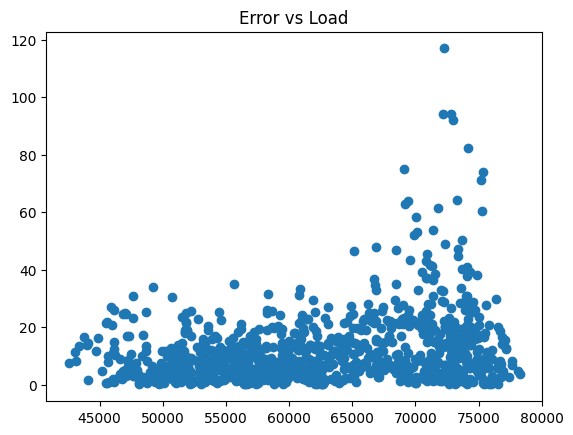

In [22]:
plt.scatter(df_test["wind"], df_test["abs_error"])
plt.title("Error vs Wind")
plt.show()

plt.scatter(df_test["load"], df_test["abs_error"])
plt.title("Error vs Load")
plt.show()

Errors tend to increase during high wind or high load conditions, indicating that extreme supply or demand situations are harder for the model to predict accurately.

In [23]:
df_test.sort_values("abs_error", ascending=False).head(10)

,price,load,wind,solar,hour,dayofweek,month,hour_sin,hour_cos,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_48,rolling_mean_168,is_weekend,prediction,error,abs_error
timestamp,,,,,,,,,,,,,,,,,,,,
2026-01-08 14:00:00,264.59,72240.73,7515.98,2288.14,14,3,1,-5.000000e-01,-0.866025,95.23,130.70,0.02,126.264167,50.308471,117.391042,97.924702,0,147.698471,116.891529,116.891529
2026-01-08 15:00:00,264.42,72161.14,8063.31,854.10,15,3,1,-7.071068e-01,-0.707107,101.84,136.99,3.51,133.320833,57.175348,120.180417,99.499524,0,170.299728,94.120272,94.120272
2026-01-08 16:00:00,259.49,72799.27,9302.65,82.11,16,3,1,-8.660254e-01,-0.500000,106.38,145.01,10.34,140.095000,62.652276,122.835208,101.052560,0,165.405212,94.084788,94.084788
2026-01-08 13:00:00,236.22,72960.10,8028.91,3278.96,13,3,1,-2.588190e-01,-0.965926,93.16,130.20,-0.01,120.303333,44.898201,115.182292,96.518571,0,144.133209,92.086791,92.086791
2026-01-08 12:00:00,220.27,74126.48,9373.04,3460.42,12,3,1,1.224647e-16,-1.000000,96.34,134.43,-0.01,115.139583,39.730329,113.393958,95.207381,0,137.881790,82.388210,82.388210
2026-01-20 16:00:00,276.74,69123.83,7991.58,1227.40,16,1,1,-8.660254e-01,-0.500000,194.89,114.88,122.15,151.726667,46.302333,138.774375,117.388869,0,201.693039,75.046961,75.046961
2026-01-08 10:00:00,207.93,75361.21,13360.69,1802.74,10,3,1,5.000000e-01,-0.866025,108.31,154.84,0.00,106.273333,26.774611,110.916250,92.701190,0,133.944901,73.985099,73.985099
2026-01-08 11:00:00,213.11,75214.25,11321.00,2798.72,11,3,1,2.588190e-01,-0.965926,99.94,147.27,0.00,110.424167,33.882572,112.022292,93.938869,0,141.982040,71.127960,71.127960
2026-01-20 08:00:00,262.78,73302.96,9991.85,1678.54,8,1,1,8.660254e-01,-0.500000,175.98,105.68,129.81,149.415000,37.652292,130.585000,116.168512,0,198.723724,64.056276,64.056276
